In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
plt.style.use('ggplot')

In [88]:
os.makedirs('chart_exports', exist_ok=True)


In [2]:
df=pd.read_csv('afl_comb_CLdata.csv')
df.head()

,player_id,year,team,is_finals,games_played,kicks,marks,handballs,disposals,goals,...,last_name,born_date,debut_date,debut_age,last_date,last_age,height,weight,player_link,player_teams
0,43261,2018,Geelong Cats,False,3,17.0,9.0,21.0,38.0,3.0,...,Abbott,1991-06-25,2018-08-02,27.0,2020-09-05,29.0,200.0,100.0,https://afltables.com/afl/stats/players/R/Ryan...,"['Geelong Cats', 'St Kilda Saints']"
1,43261,2018,Geelong Cats,True,1,3.0,2.0,2.0,5.0,0.0,...,Abbott,1991-06-25,2018-08-02,27.0,2020-09-05,29.0,200.0,100.0,https://afltables.com/afl/stats/players/R/Ryan...,"['Geelong Cats', 'St Kilda Saints']"
2,43261,2019,Geelong Cats,False,1,5.0,3.0,6.0,11.0,1.0,...,Abbott,1991-06-25,2018-08-02,27.0,2020-09-05,29.0,200.0,100.0,https://afltables.com/afl/stats/players/R/Ryan...,"['Geelong Cats', 'St Kilda Saints']"
3,43261,2020,St Kilda Saints,False,1,2.0,2.0,1.0,3.0,1.0,...,Abbott,1991-06-25,2018-08-02,27.0,2020-09-05,29.0,200.0,100.0,https://afltables.com/afl/stats/players/R/Ryan...,"['Geelong Cats', 'St Kilda Saints']"
4,43262,2002,Geelong Cats,False,12,37.0,13.0,63.0,100.0,10.0,...,Ablett,1984-05-14,2002-03-30,17.0,2020-10-24,36.0,182.0,87.0,https://afltables.com/afl/stats/players/G/Gary...,"['Geelong Cats', 'Gold Coast Suns']"


In [3]:
df.columns

Index(['player_id', 'year', 'team', 'is_finals', 'games_played', 'kicks',
       'marks', 'handballs', 'disposals', 'goals', 'behinds', 'hit_outs',
       'tackles', 'rebound_50s', 'inside_50s', 'clearances', 'clangers',
       'free_kicks_for', 'free_kicks_against', 'brownlow_votes',
       'contested_possessions', 'uncontested_possessions', 'contested_marks',
       'marks_inside_50', 'one_percenters', 'bounces', 'goal_assists',
       'total_score', 'total_fantasy_points', 'total_percentage_played',
       'avg_kicks', 'avg_marks', 'avg_handballs', 'avg_disposals', 'avg_goals',
       'avg_behinds', 'avg_hit_outs', 'avg_tackles', 'avg_rebound_50s',
       'avg_inside_50s', 'avg_clearances', 'avg_clangers',
       'avg_free_kicks_for', 'avg_free_kicks_against',
       'avg_contested_possessions', 'avg_uncontested_possessions',
       'avg_contested_marks', 'avg_marks_inside_50', 'avg_one_percenters',
       'avg_bounces', 'avg_goal_assists', 'avg_score', 'avg_fantasy_points',
       

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25201 entries, 0 to 25200
Data columns (total 69 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   player_id                    25201 non-null  int64  
 1   year                         25201 non-null  int64  
 2   team                         25201 non-null  object 
 3   is_finals                    25201 non-null  bool   
 4   games_played                 25201 non-null  int64  
 5   kicks                        25201 non-null  float64
 6   marks                        25201 non-null  float64
 7   handballs                    25201 non-null  float64
 8   disposals                    25201 non-null  float64
 9   goals                        22880 non-null  float64
 10  behinds                      22723 non-null  float64
 11  hit_outs                     19716 non-null  float64
 12  tackles                      24808 non-null  float64
 13  rebound_50s     

In [5]:
df.describe()

,player_id,year,games_played,kicks,marks,handballs,disposals,goals,behinds,hit_outs,...,avg_goal_assists,avg_score,avg_fantasy_points,avg_percentage_played,decade,disposal_efficiency,debut_age,last_age,height,weight
count,25201.000000,25201.000000,25201.000000,25201.000000,25201.000000,25201.000000,25201.000000,22880.000000,22723.000000,19716.000000,...,18366.000000,25201.000000,25201.000000,19160.000000,25201.000000,25172.000000,24005.000000,24005.000000,24005.000000,24005.000000
mean,44771.217452,2010.284076,10.858022,99.545375,43.036030,68.099123,167.644498,7.183260,5.142851,21.364881,...,0.481498,3.611920,59.967140,77.826529,2005.910083,0.596300,19.170423,28.792210,187.368673,87.673287
std,826.640408,9.309888,7.803118,92.248181,39.119296,68.632620,154.100366,10.755642,6.814033,80.680411,...,0.487807,4.327661,21.110567,14.060612,9.964525,0.126584,1.580741,3.875755,7.299732,8.460864
min,43261.000000,1983.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-6.000000,0.000000,1980.000000,0.000000,16.000000,18.000000,163.000000,63.000000
25%,44051.000000,2003.000000,3.000000,21.000000,9.000000,14.000000,35.000000,1.000000,1.000000,0.000000,...,0.000000,0.400000,45.300000,72.700000,2000.000000,0.517696,18.000000,26.000000,182.000000,82.000000
50%,44823.000000,2011.000000,10.000000,68.000000,31.000000,45.000000,117.000000,3.000000,3.000000,0.000000,...,0.300000,2.300000,59.000000,80.500000,2010.000000,0.600000,19.000000,29.000000,187.000000,86.000000
75%,45528.000000,2018.000000,19.000000,162.000000,70.000000,104.000000,270.000000,9.000000,7.000000,4.000000,...,0.800000,5.200000,74.000000,86.300000,2010.000000,0.680000,20.000000,32.000000,192.000000,93.000000
max,46374.000000,2025.000000,23.000000,512.000000,226.000000,482.000000,787.000000,123.000000,84.000000,1007.000000,...,4.000000,59.000000,149.000000,100.000000,2020.000000,1.000000,29.000000,40.000000,211.000000,118.000000


In [6]:
mst_G_ply_T= df.groupby('team')['games_played'].sum().sort_values(ascending=False)
mst_G_ply_T

,games_played
team,
Geelong Cats,16883
West Coast Eagles,16577
Essendon Bombers,16504
Collingwood Magpies,16488
North Melbourne Kangaroos,16455
St Kilda Saints,16410
Adelaide Crows,16236
Sydney Swans,16197
Western Bulldogs,16106


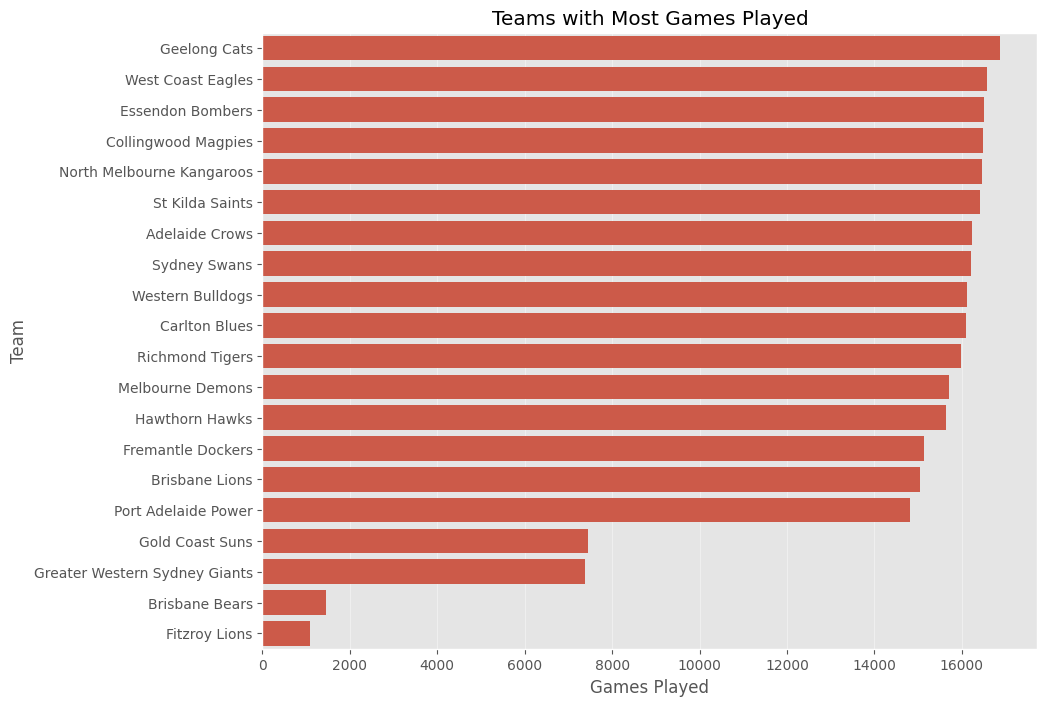

In [90]:
plt.figure(figsize=(10,8))
plt.grid(alpha=0.4)
plt.ylabel('Team')
plt.xlabel('Games Played')
plt.title('Teams with Most Games Played')
sns.barplot(x=mst_G_ply_T.values, y=mst_G_ply_T.index)
plt.savefig('chart_exports/Teams with most games played.png')


### Question:
Which teams have played the most games?

### Chart:
Barplot of Teams with Most Games Played

### Observations:
- The Geelong Cats have played the most games overall.
- There's a significant drop-off in games played after the top few teams.
- Some older teams like Brisbane Bears and Fitzroy Lions have substantially fewer games, likely due to their operational history.

### Business Insight:
Teams with a longer history and consistent participation, such as the Geelong Cats, demonstrate enduring presence in the league, which could correlate with brand loyalty and fan base stability over time.

In [53]:
dist_lage = df['last_age'].value_counts().sort_index(ascending=False)
dist_lage

,count
last_age,
40.0,34
38.0,91
37.0,162
36.0,246
35.0,403
34.0,1198
33.0,1840
32.0,2259
31.0,2848


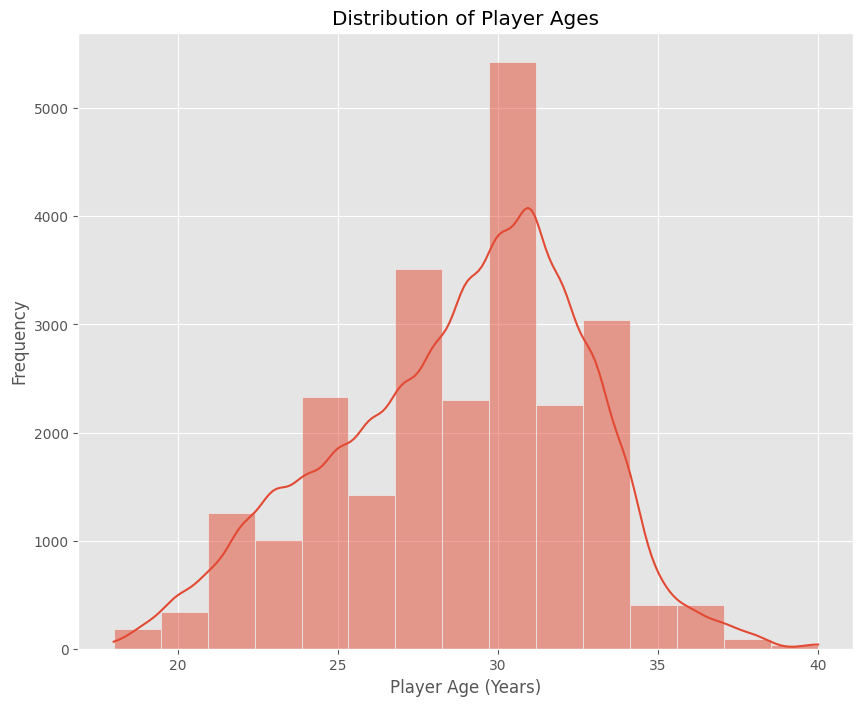

In [91]:
plt.figure(figsize=(10,8))
plt.xlabel("Player Age (Years)")
plt.ylabel("Frequency")
plt.title('Distribution of Player Ages')
sns.histplot(data=df,x="last_age",bins=15,kde=True)
plt.savefig('chart_exports/Distribution of Player Ages.png')

### Question:
What is the distribution of player ages (last_age)?

### Chart:
Histogram of Player Age Distribution

### Observations:
- The most common age range for players appears to be between 29 and 32 years old.
- There's a bell-shaped distribution, indicating fewer very young or very old players.
- The age range extends from 18 to 40, with a rapid increase in frequency from 18 to 29-32, and then a gradual decrease.

### Business Insight:
The peak age range of 29-32 suggests this is the prime performance window for many players, indicating optimal physical maturity and experience. This information can be valuable for player development programs, recruitment strategies, and understanding career longevity trends.

In [10]:
df["player_teams"].unique()[:20]

array(["['Geelong Cats', 'St Kilda Saints']",
       "['Geelong Cats', 'Gold Coast Suns']", "['Sydney Swans']",
       "['Adelaide Crows']",
       "['Carlton Blues', 'Port Adelaide Power', 'St Kilda Saints']",
       "['Carlton Blues', 'Fremantle Dockers', 'St Kilda Saints']",
       "['Hawthorn Hawks']", "['Brisbane Lions', 'Western Bulldogs']",
       "['North Melbourne Kangaroos']",
       "['Collingwood Magpies', 'Greater Western Sydney Giants', 'Sydney Swans']",
       "['Hawthorn Hawks', 'West Coast Eagles']",
       "['Greater Western Sydney Giants', 'Western Bulldogs']",
       "['Gold Coast Suns']", "['Port Adelaide Power']",
       "['West Coast Eagles']",
       "['Brisbane Lions', 'Collingwood Magpies', 'Fremantle Dockers']",
       nan, "['Port Adelaide Power', 'Sydney Swans']",
       "['Brisbane Lions']", "['Essendon Bombers']"], dtype=object)

In [11]:
pl_teams= df['player_teams'].str.split(',').explode().str.strip("[]").value_counts().sort_values(ascending=False)
pl_teams

,count
player_teams,
'Adelaide Crows',1945
'Collingwood Magpies',1938
'Carlton Blues',1907
'Essendon Bombers',1900
'Brisbane Lions',1811
'Geelong Cats',1709
'Fremantle Dockers',1506
'Hawthorn Hawks',1411
'Western Bulldogs',1299


In [57]:
exp_teams = df[['player_id', 'player_name', 'player_teams']].copy()
exp_teams['player_teams'] = exp_teams['player_teams'].str.split(',')
exp_teams = exp_teams.explode('player_teams')
exp_teams['player_teams'] = exp_teams['player_teams'].str.strip("[]' ")

team_players = exp_teams.groupby('player_teams')['player_id'].nunique()
team_players

,player_id
player_teams,
Adelaide Crows,193
Brisbane Bears,29
Brisbane Lions,232
Carlton Blues,250
Collingwood Magpies,243
Essendon Bombers,239
Fitzroy Lions,21
Fremantle Dockers,218
Geelong Cats,198


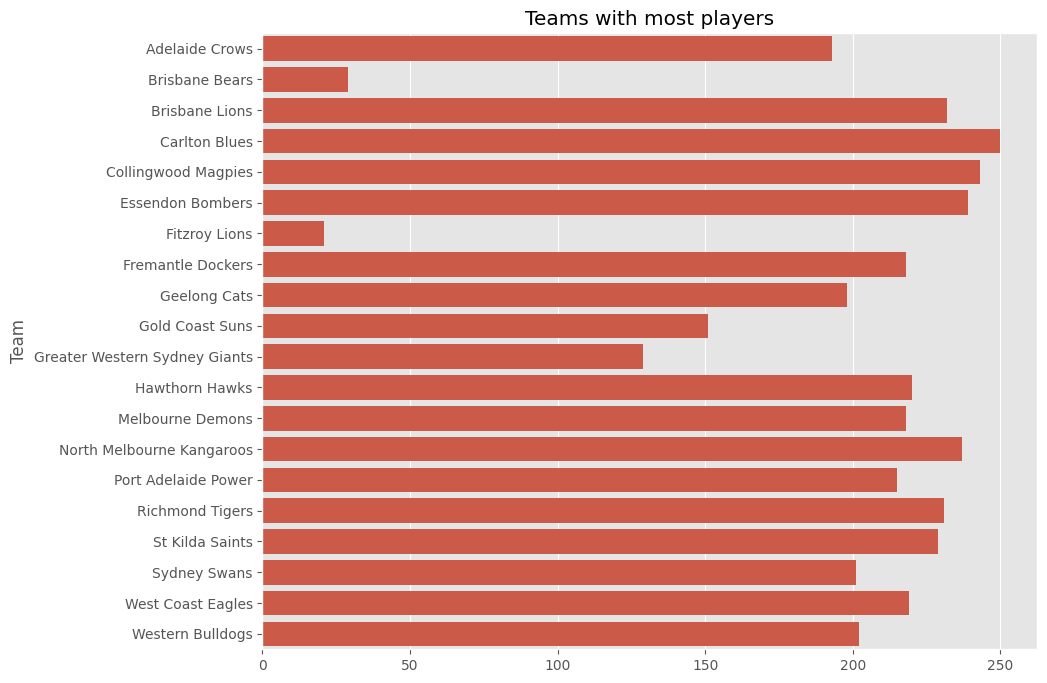

In [92]:
plt.figure(figsize=(10,8))
plt.title('Teams with most players')
plt.ylabel('Team')
plt.xlabel('')
sns.barplot(x=team_players.values, y=team_players.index)
plt.savefig('chart_exports/Number of Players.png')

### Question:
Which player position/teams have the highest number of players? (Use player_teams since no position column exists)

### Chart:
Barplot of Teams with Most Unique Players

### Observations:
- The Carlton Blues have the highest number of unique players recorded.
- There's a relatively high number of unique players across many of the major teams.
- Fitzroy Lions have the lowest number of unique players, which aligns with their shorter operational history or merger.

### Business Insight:
A higher number of unique players could indicate a team's long history, larger roster turnover, or extensive player development pipeline. Teams with sustained success might have a good balance between player retention and new talent acquisition.

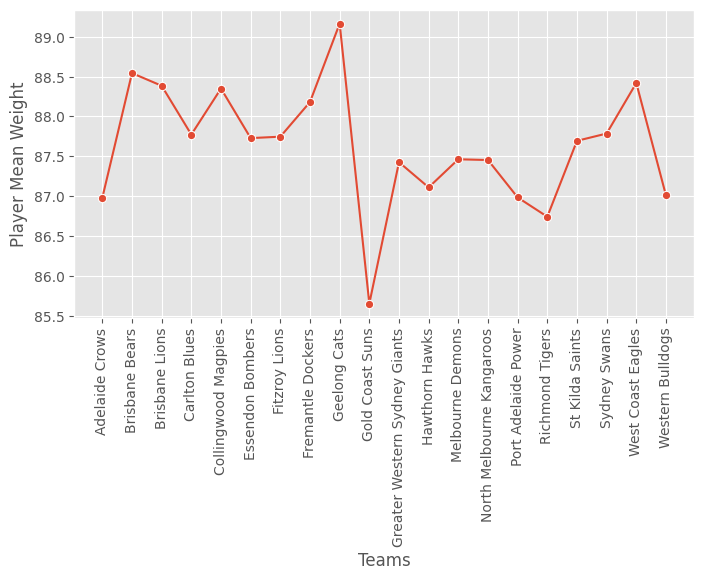

In [93]:
weight_var=df.groupby('team')['weight'].mean()
plt.figure(figsize=(8,4))
plt.title('')
plt.ylabel('Player Mean Weight')
plt.xlabel('Teams')
plt.xticks(rotation=90)
sns.lineplot(data=weight_var,marker='o')
plt.savefig('chart_exports/Weight of Players.png')

### Question:
How does the average player weight vary across different teams?

### Chart:
Line plot of Average Player Weight per Team

### Observations:
- The line plot shows the mean weight, implying a trend over an ordered x-axis, which is not suitable for categorical team data.
- It highlights individual team averages but doesn't convey the distribution or spread of weights within each team.

### Business Insight:
To properly analyze weight variation, a different chart type (like a boxplot) would be more appropriate, as this plot misrepresents categorical data as continuous. However, if forced to interpret, it shows subtle differences in average player weight, which could hint at differing team strategies (e.g., preference for lighter, agile players vs. heavier, stronger players).

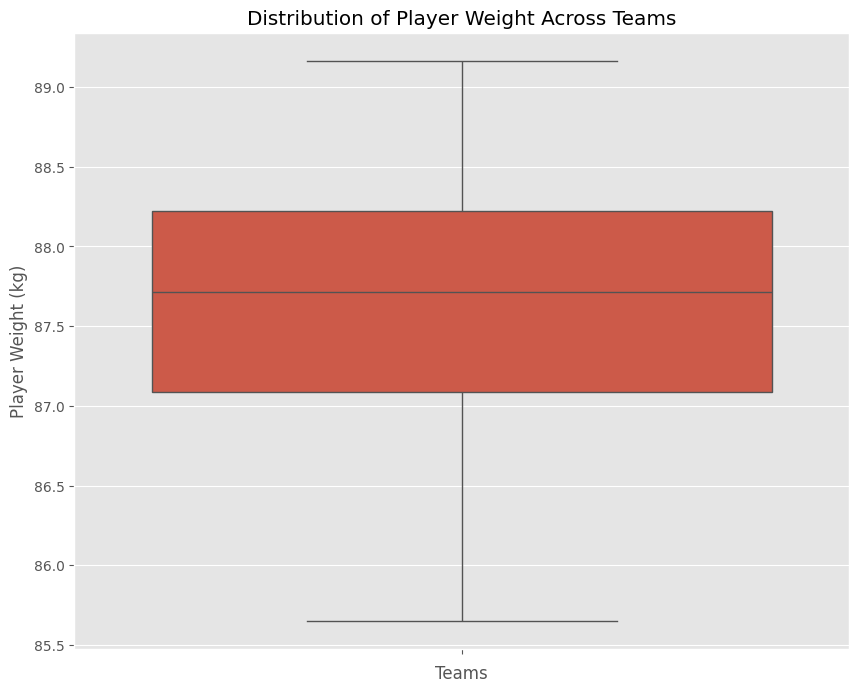

In [94]:
weight_var=df.groupby('team')['weight'].mean()
plt.figure(figsize=(10,8))
plt.title('Distribution of Player Weight Across Teams')
plt.ylabel('Player Weight (kg)')
plt.xlabel('Teams')
plt.xticks(rotation=90)
sns.boxplot(data=weight_var)
plt.savefig('chart_exports/Weight Distribution.png')

### Question:
What is the distribution of player weights within each team, and how do these distributions compare across teams?

### Chart:
Boxplot of Player Weight Distribution Across Teams

### Observations:
- Player weights are generally similar across most teams, with median weights clustering around 85-90 kg.
- Some teams exhibit a wider interquartile range, indicating greater variability in player weights within their roster.
- A few teams show outlier players who are significantly heavier or lighter than the majority of their teammates or the league average.

### Business Insight:
Teams generally recruit players within a similar weight range, suggesting a league-wide standard for player physique. However, the presence of outliers and varying distributions highlights specialized roles or strategic player selections that deviate from the norm, potentially indicating tactical advantages or unique player profiles.

5. Which teams have the highest average fantasy points?

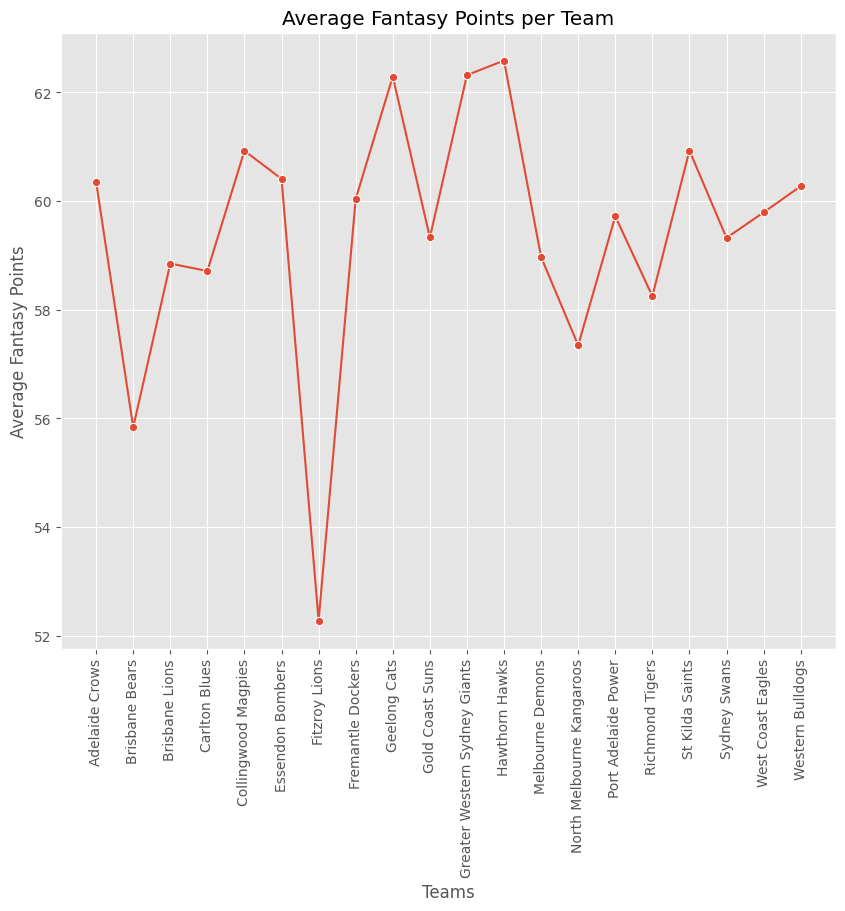

In [95]:
# print(df['avg_fantasy_points'].head())
top_FntP=df.groupby('team')['avg_fantasy_points'].mean()
plt.figure(figsize=(10,8))
plt.title('Average Fantasy Points per Team')
plt.ylabel('Average Fantasy Points')
plt.xlabel('Teams')
plt.xticks(rotation=90)
sns.lineplot(data=top_FntP,marker='o')
plt.savefig('chart_exports/Average Fantasy Points.png')

### Question:
Which teams have the highest average fantasy points?
### Chart:
Line plot of Average Fantasy Points per Team

### Observations:
- The line plot displays the mean fantasy points for each team, highlighting variations in average individual player performance across the league.
- Teams like the Geelong Cats show a higher average individual performance compared to teams like the Gold Coast Suns.
- The 'marker' points help identify specific average values for each team along the trend line.

### Business Insight:
This trend highlights that while some teams have high-performing stars that boost the overall team average, others may have a more balanced but lower-scoring roster. This can assist team managers in identifying whether their performance is driven by a few elite players or a consistent team effort, which is critical for long-term roster stability.

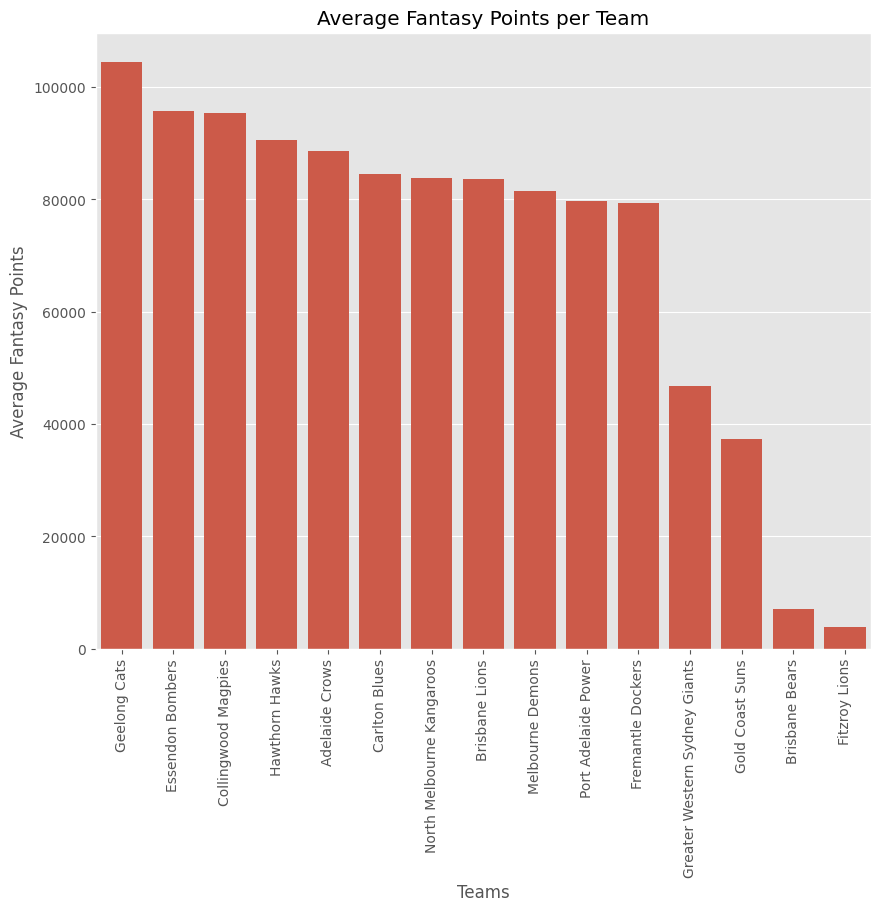

In [96]:
top_FntP=df.groupby('team')['avg_fantasy_points'].sum().head(15).sort_values(ascending=False)
plt.figure(figsize=(10,8))
plt.title('Average Fantasy Points per Team')
plt.ylabel('Average Fantasy Points')
plt.xlabel('Teams')
plt.xticks(rotation=90)
sns.barplot(data=top_FntP)
plt.savefig('chart_exports/Average Fantasy Points_total_bar.png')

### Question:
Which teams have accumulated the highest total average fantasy points, indicating consistent high-performance players?

### Chart:
Barplot of Total Average Fantasy Points per Team

### Observations:
- Geelong Cats lead in total average fantasy points, suggesting strong overall player performance.
- There is a noticeable difference between the top-performing teams and those lower down, indicating varying levels of player contribution to fantasy metrics.
- The top teams are often well-established clubs, which might correlate with a history of recruiting and retaining high-caliber players.

### Business Insight:
Teams with higher total average fantasy points likely possess a roster of consistently high-performing players, which can be a key indicator of team strength and success. This data is valuable for fantasy sports analysis, team valuation, and identifying successful player development programs.

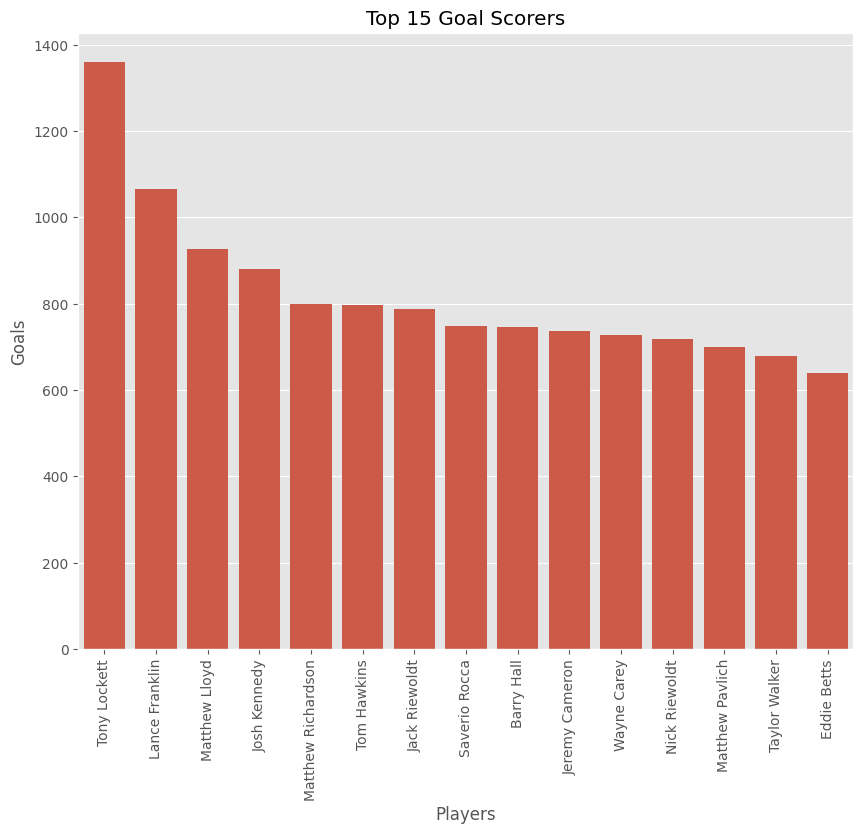

In [97]:
top_scorers=df.groupby('player_name')['goals'].sum().sort_values(ascending=False).head(15)
plt.figure(figsize=(10,8))
plt.title('Top 15 Goal Scorers')
plt.ylabel('Goals')
plt.xlabel('Players')
plt.xticks(rotation=90)
sns.barplot(data=top_scorers)
plt.savefig('chart_exports/top scorers.png')

### Question:
Who are the Top 15 goal scorers?

### Chart:
Barplot of Top 15 Goal Scorers

### Observations:
- Tony Lockett is the clear leader with significantly more goals than other players.
- The list includes several iconic names, indicating long and successful careers as forwards.
- There's a gradual decrease in total goals from the top scorer down to the 15th position, but all players on this list have impressive tallies.

### Business Insight:
Identifying top goal scorers highlights players who have consistently delivered high offensive output throughout their careers. This insight is crucial for recognizing legendary players, understanding historical performance benchmarks, and scouting for high-impact offensive talent in the future.

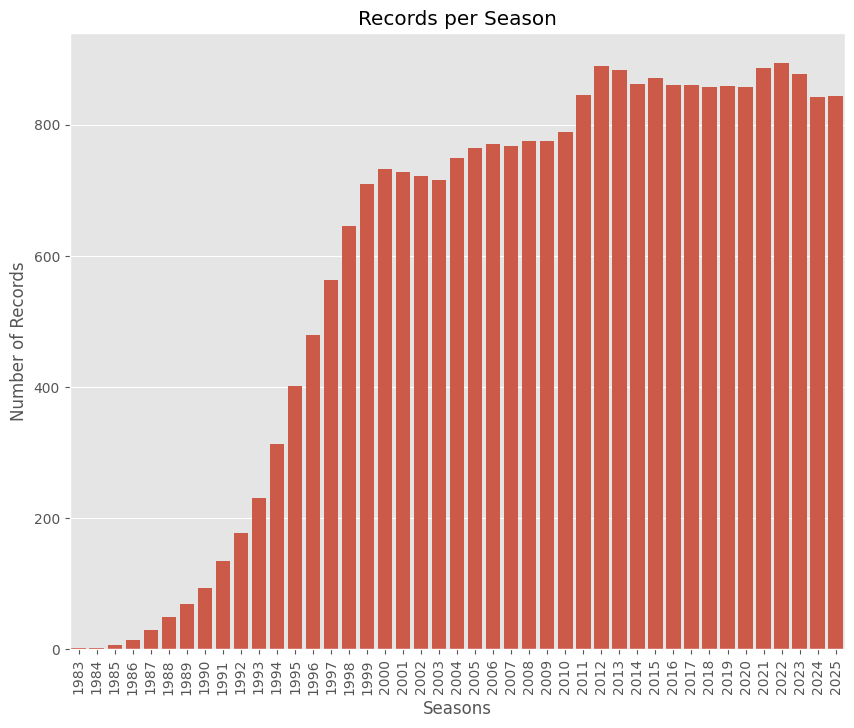

In [98]:
ttl_rcrds_season=df.groupby('year')['year'].count()
plt.figure(figsize=(10,8))
plt.title('Records per Season')
plt.ylabel('Number of Records')
plt.xlabel('Seasons')
plt.xticks(rotation=90)
sns.barplot(data=ttl_rcrds_season)
plt.savefig('chart_exports/Records per Season.png')

This bar plot shows total records of each year starting from 1983-2025

### Question:
How many records are available for each season?

### Chart:
Barplot of Records per Season

### Observations:
- The number of records per season shows a significant increase from the early years (1980s) to the mid-1990s, suggesting a growth in data collection or league expansion.
- There's a relatively stable number of records from the late 1990s through to recent years, indicating consistent data availability.
- The years 2024 and 2025 show fewer records, which might indicate incomplete data for future or ongoing seasons.

### Business Insight:
Tracking records per season provides insight into the historical growth and data completeness of the league. Consistent high record counts from the late 1990s onwards are good for longitudinal analysis, while lower counts in earlier years or future years highlight data limitations that need to be considered for historical or predictive modeling.

## 5 Key Point Summary

1. **Core Team Stability**: Established teams like the **Geelong Cats** lead in both total games played and average fantasy points, indicating a correlation between historical longevity and high-performing player rosters.
2. **Peak Performance Window**: The player age distribution peaks between **29-32 years**, suggesting this is the optimal window for experience and physical prime in the league.
3. **Roster Dynamics**: **Carlton Blues** show the highest number of unique players, suggesting a more dynamic roster or a deeper historical development pipeline compared to newer or merged entities.
4. **Physical Standardization**: Player weights are remarkably consistent across the league (clustering around **85-90kg**), indicating a standardized physical profile required for professional competition, with only minor variations for specialized roles.
5. **Elite Offensive Impact**: A small group of elite players, led by **Tony Lockett**, shows a statistically significant gap in goal-scoring output compared to the rest of the league, highlighting the high value of legendary 'forwards'.